# ml_40 — Diagnostic training-data amount sweep: three controlled variations

Diagnostic companion to `ml_38`/`ml_39`. The uniform-split sweep results (e.g. `interp_v1.png`) show no clean
error-vs-training-amount trend, unlike the original January/February fixed-architecture sweep (resonator
`ml_01`, `SWEEP_DATA_AMOUNT` mode), which held every hyperparameter fixed, kept the validation set fixed,
averaged over seeds, and evaluated the inverse model directly. The current sweeps changed all of those at once:
a fresh Keras-tuner architecture per slice, a surrogate retrained per slice (so the evaluation yardstick changes
with every point), and a single seed per slice.

This notebook isolates those factors with **5 slices (20/40/60/80/100% of the training pool), one model
per slice, and 5 predicted test samples per slice** and
three variations:

1. **`tuned_inverse_hp_fixed_surrogate`** — per-slice tuner-best *inverse* hyperparameters (read from the
   already-completed ml_38 search CSV, so no tuner runs here), while the surrogate stays the frozen all-time-best
   model (`best_keras_model_model2_surrogate.keras`). Tests whether per-slice HP retuning hides the trend.
2. **`fixed_hp_retrain_both`** — one fixed hyperparameter set for every slice (the HPs of the all-time-best
   surrogate and inverse models, read straight out of the saved `.keras` files like ml_37 does), with **both**
   models retrained on each slice. Tests whether surrogate retraining hides the trend even with fixed HP.
3. **`fixed_hp_fixed_surrogate`** — fixed best HPs *and* the frozen best surrogate; only the inverse model is
   retrained on each limited training slice. The closest analogue of the original February inverse-only sweep.

Same uniform split as ml_35/ml_36/ml_38/ml_39 (`SPLIT_SEED = 42`), so the nested training slices and the fixed
20 Ansys-comparable test targets are identical.

Every row also gets `test_*_via_best_surrogate` columns: the trained inverse's geometry pushed through the frozen
all-time-best surrogate — a *constant* yardstick across all variations and slices. For variations 1 and 3 it
equals the loop metric; for variation 2 it is the number to trust, because there the loop metric is measured
through a per-slice surrogate whose own quality changes with the slice.

Outputs per variation:

- `data_amount_sweep_uniform_diag_{variation}.csv` — one row per (fraction, seed), same schema as the ml_39
  per-seed CSVs (plus `variation` and the `*_via_best_surrogate` columns at the end)
- `data_amount_sweep_uniform_diag_{variation}_summary.csv` — across-seed mean/std per fraction
- `predictions_per_sample_uniform_diag_{variation}.csv` — standard ml_37 per-sample prediction format
- models under `model/uniform_diagnostic_sweep/{variation}/`
- `plots/uniform_diagnostic_sweep_comparison.png`

A fourth, standalone section at the bottom sweeps the training amount for **just the forward surrogate**
(fixed all-time-best surrogate HPs, no retuning, no inverse model), evaluated directly on the held-out
uniform test set and averaged over `SURROGATE_ONLY_SEEDS`. Its outputs follow the same naming with
`{variation} = surrogate_only`, plus `plots/uniform_diagnostic_sweep_surrogate_only.png`.


In [12]:
from __future__ import annotations

import gc
import json
import os
import sys
import zipfile
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
# Use the async CUDA allocator to avoid fragmentation OOMs over the long
# multi-fraction training loop. Must be set before TensorFlow touches the GPU.
os.environ.setdefault("TF_GPU_ALLOCATOR", "cuda_malloc_async")

import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout, Input, LeakyReLU
from tensorflow.keras.models import load_model


tf.keras.backend.set_floatx("float32")

# Let GPU memory grow on demand instead of pre-reserving it all, which also
# reduces fragmentation OOMs during the long run.
for _gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except Exception:
        pass


# This notebook can be run either from the transmon experiment folder or from the
# repo root. The block below tries both so local paths do not need hard-coding.
HERE = Path.cwd()
EXPERIMENT_RELATIVE = Path("experiments/model_predict_qubit_TransmonCross_Hamiltonian_params")

if (HERE / "metadata" / "qubit-TransmonCross-Hamiltonian_params.json").exists():
    EXPERIMENT_DIR = HERE
elif (HERE / EXPERIMENT_RELATIVE / "metadata" / "qubit-TransmonCross-Hamiltonian_params.json").exists():
    EXPERIMENT_DIR = HERE / EXPERIMENT_RELATIVE
else:
    raise FileNotFoundError(
        "Could not find the transmon-cross metadata file. "
        "Run this notebook from the repo root or from the transmon experiment folder."
    )

if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

from parameters_surrogate_defined_loss import (  # noqa: E402
    EPOCHS,
    MODEL_DIR as PARAM_MODEL_DIR,
    SCALERS_DIR as PARAM_SCALERS_DIR,
    TRAIN_BATCH_SIZE,
    TRAIN_EARLY_STOPPING_PATIENCE,
    TRAIN_LOSS,
)
from parameters_surrogate import (  # noqa: E402
    EPOCHS as SURROGATE_EPOCHS,
    TRAIN_BATCH_SIZE as SURROGATE_TRAIN_BATCH_SIZE,
    TRAIN_EARLY_STOPPING_PATIENCE as SURROGATE_TRAIN_EARLY_STOPPING_PATIENCE,
    TRAIN_LOSS as SURROGATE_TRAIN_LOSS,
)

METADATA_DIR = EXPERIMENT_DIR / "metadata"
METADATA_PATH = METADATA_DIR / "qubit-TransmonCross-Hamiltonian_params.json"

MODEL_DIR = Path(PARAM_MODEL_DIR)
SCALERS_DIR = Path(PARAM_SCALERS_DIR)

# All-time-best models: the fixed hyperparameters for variations 2 and 3 are read
# straight out of these files (same machinery as ml_37), and the frozen surrogate
# used by variations 1 and 3 is the best surrogate itself.
BEST_SURROGATE_MODEL_PATH = MODEL_DIR / "best_keras_model_model2_surrogate.keras"
BEST_COMBINED_MODEL_CANDIDATES = [
    MODEL_DIR / "surrogate_loss_2in_3out_best_model.keras",
    MODEL_DIR / "best_keras_model_surrogate_defined_loss.keras",
]
BEST_COMBINED_MODEL_PATH = next((p for p in BEST_COMBINED_MODEL_CANDIDATES if p.exists()), None)
if BEST_COMBINED_MODEL_PATH is None:
    raise FileNotFoundError(f"No reference combined inverse+surrogate model found in {MODEL_DIR}")
if not BEST_SURROGATE_MODEL_PATH.exists():
    raise FileNotFoundError(f"Missing all-time-best surrogate: {BEST_SURROGATE_MODEL_PATH}")

# Per-slice tuner-best inverse HP for variation 1 come from the completed ml_38
# search (no tuner runs in this notebook, so the whole thing stays fast).
HP_SOURCE_CSV = EXPERIMENT_DIR / "data_amount_sweep_uniform_keras_tuner_seed0.csv"

# ---- diagnostic sweep grid: deliberately small so all three variations run fast ----
FRACTIONS = (0.2, 0.4, 0.6, 0.8, 1.0)
# One trained model per slice. (The first run also trained seeds 2-5; those models
# and their sweep-CSV rows still exist and are simply ignored with SEEDS = (1,).)
SEEDS = (1,)

# Same uniform random split as ml_35/ml_36/ml_38/ml_39.
TEST_FRACTION = 0.15
VAL_FRACTION = 0.15
SPLIT_SEED = 42

# The three variations (see the markdown cell above).
VARIATION_TUNED_INVERSE = "tuned_inverse_hp_fixed_surrogate"
VARIATION_FIXED_HP_RETRAIN_BOTH = "fixed_hp_retrain_both"
VARIATION_FIXED_HP_FIXED_SURROGATE = "fixed_hp_fixed_surrogate"
RUN_VARIATIONS = (
    VARIATION_TUNED_INVERSE,
    VARIATION_FIXED_HP_RETRAIN_BOTH,
    VARIATION_FIXED_HP_FIXED_SURROGATE,
)

SWEEP_MODEL_ROOT = MODEL_DIR / "uniform_diagnostic_sweep"
SWEEP_MODEL_ROOT.mkdir(parents=True, exist_ok=True)

# All diagnostic-sweep CSVs live in their own results folder; the Ansys-format
# exports go under results/validation next to the ml_36/ml_39 export folders.
DIAG_RESULTS_DIR = EXPERIMENT_DIR / "results" / "data_amount_sweep_uniform_diag"
DIAG_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
ANSYS_EXPORT_DIR = EXPERIMENT_DIR / "results" / "validation" / "data_amount_sweep_uniform_diag_ansys"
ANSYS_EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def sweep_csv_path(variation: str) -> Path:
    return DIAG_RESULTS_DIR / f"data_amount_sweep_uniform_diag_{variation}.csv"


def summary_csv_path(variation: str) -> Path:
    return DIAG_RESULTS_DIR / f"data_amount_sweep_uniform_diag_{variation}_summary.csv"


def predictions_csv_path(variation: str) -> Path:
    return DIAG_RESULTS_DIR / f"predictions_per_sample_uniform_diag_{variation}.csv"


# Runs before the folder reorganisation wrote these CSVs to EXPERIMENT_DIR
# directly; move any strays into DIAG_RESULTS_DIR so resume still finds them.
for _v in RUN_VARIATIONS:
    for _new in (sweep_csv_path(_v), summary_csv_path(_v), predictions_csv_path(_v)):
        _old = EXPERIMENT_DIR / _new.name
        if _old.exists() and not _new.exists():
            _old.rename(_new)
            print(f"moved {_old.name} -> {_new.relative_to(EXPERIMENT_DIR)}")


# Training-loop settings shared with ml_21/ml_38/ml_39.
INVERSE_EPOCHS = EPOCHS
INVERSE_BATCH_SIZE = TRAIN_BATCH_SIZE
INVERSE_EARLY_STOPPING_PATIENCE = TRAIN_EARLY_STOPPING_PATIENCE

# Run the training sweep. Set to False if the CSVs already exist and you only want
# the summary/prediction/plot cells.
RUN_SWEEP = True

# Per-sample predictions: 5 test targets per slice, the first 5 of the fixed
# 20-target set ml_36 exports for Ansys (test_idx order), so the rows stay
# directly comparable across notebooks.
N_PRED_SAMPLES_PER_SLICE = 5

EPS = 1e-12


In [13]:
# data loading

@dataclass
class Scaler:
    min_: np.ndarray
    max_: np.ndarray

    @property
    def range_(self) -> np.ndarray:
        return np.maximum(self.max_ - self.min_, EPS)

    def transform(self, x: np.ndarray) -> np.ndarray:
        return (x - self.min_) / self.range_

    def inverse_transform(self, x: np.ndarray) -> np.ndarray:
        return x * self.range_ + self.min_


def parse_um(value: object) -> float:
    text = str(value).strip()
    for suffix in ("um", "µm", "μm"):
        if text.endswith(suffix):
            return float(text[: -len(suffix)])
    return float(text)


def load_arrays() -> tuple[np.ndarray, np.ndarray]:
    """Load Hamiltonian targets and geometry values from the SQuADDS metadata."""
    data = json.loads(METADATA_PATH.read_text())
    hamiltonian = []
    geometry = []

    for row in data:
        h = row["Hamiltonian_params"]
        opts = row["design"]["design_options"]
        readout = opts["connection_pads"]["readout"]

        hamiltonian.append(
            [
                float(h["qubit_frequency_GHz"]),
                float(h["anharmonicity_MHz"]),
            ]
        )
        geometry.append(
            [
                parse_um(readout["claw_length"]),
                parse_um(readout["ground_spacing"]),
                parse_um(opts["cross_length"]),
            ]
        )

    return np.asarray(hamiltonian, dtype=np.float64), np.asarray(geometry, dtype=np.float64)


def choose_uniform_split(
    n_rows: int,
    test_fraction: float,
    val_fraction: float,
    seed: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Draw test/validation/training-pool indices uniformly at random.

    Unlike the corner notebook, no geometry corner is held out. The test and
    validation rows are a uniform random sample from across the whole parameter
    space, and the rest becomes the training pool.
    """
    n_test = int(np.ceil(test_fraction * n_rows))
    n_val = int(np.ceil(val_fraction * n_rows))

    rng = np.random.default_rng(seed)
    perm = rng.permutation(n_rows)

    test_idx = perm[:n_test]
    val_idx = perm[n_test:n_test + n_val]
    train_pool_idx = perm[n_test + n_val:]

    return train_pool_idx, val_idx, test_idx


def uniform_training_order(train_pool_idx: np.ndarray, seed: int) -> np.ndarray:
    """
    Return a uniform random ordering (local indices) of the training pool.

    Taking the first ``n`` of this ordering gives nested uniform random subsets
    as the training fraction grows, the analogue of the corner notebook's
    far-to-near ordering but without any spatial structure.
    """
    rng = np.random.default_rng(seed + 1000)
    return rng.permutation(len(train_pool_idx))


def scaler_from_artifacts(
    values: np.ndarray,
    columns: list[str],
    path_patterns: list[str],
    label: str,
) -> tuple[Scaler, list[str]]:
    """Load per-column MinMaxScaler ranges when present, otherwise fit on metadata."""
    mins = []
    maxs = []
    sources = []

    for i, col in enumerate(columns):
        loaded = None
        source = None
        for pattern in path_patterns:
            candidate = SCALERS_DIR / pattern.format(col=col)
            if candidate.exists():
                loaded = joblib.load(candidate)
                source = str(candidate)
                break

        if loaded is not None:
            mins.append(float(np.asarray(loaded.data_min_).reshape(-1)[0]))
            maxs.append(float(np.asarray(loaded.data_max_).reshape(-1)[0]))
            sources.append(source)
        else:
            mins.append(float(np.min(values[:, i])))
            maxs.append(float(np.max(values[:, i])))
            sources.append(f"metadata fallback: {label}.{col}")

    return Scaler(np.asarray(mins), np.asarray(maxs)), sources


In [14]:
# building the split and scalers

h_raw, geom_raw_um = load_arrays()
geom_raw_si = geom_raw_um * 1e-6

HAMILTONIAN_COLUMN_NAMES = (METADATA_DIR / "X_names").read_text().splitlines()
QISKIT_PARAM_NAMES = np.load(METADATA_DIR / "y_columns.npy", allow_pickle=True).astype(str).tolist()

train_pool_idx, val_idx, test_idx = choose_uniform_split(
    len(geom_raw_um),
    TEST_FRACTION,
    VAL_FRACTION,
    SPLIT_SEED,
)

# Make sure the held-out validation/test rows never leak into the training pool.
assert len(np.intersect1d(train_pool_idx, val_idx)) == 0
assert len(np.intersect1d(train_pool_idx, test_idx)) == 0
assert len(np.intersect1d(val_idx, test_idx)) == 0

# Uniform random ordering of the training pool; nested subsets grow with fraction.
uniform_order = uniform_training_order(train_pool_idx, SPLIT_SEED)

# For the actual model inputs/outputs, use the saved scaler artifacts from the
# existing repo workflow. These are fit on the complete dataset, so the scaled
# [0, 1] range used by the range penalty is the total space spanned by the
# complete dataset. This also keeps the surrogate in its original scaled space.
h_model_scaler, h_scaler_sources = scaler_from_artifacts(
    h_raw,
    HAMILTONIAN_COLUMN_NAMES,
    ["scaler_X_{col}.save", "scaler_X_linear_{col}.save"],
    "Hamiltonian",
)
geom_inverse_scaler, geom_inverse_scaler_sources = scaler_from_artifacts(
    geom_raw_si,
    QISKIT_PARAM_NAMES,
    ["scaler_y_{col}_one_hot_encoding.save"],
    "inverse_qiskit",
)
geom_surrogate_scaler, geom_surrogate_scaler_sources = scaler_from_artifacts(
    geom_raw_si,
    QISKIT_PARAM_NAMES,
    ["scaler_y_linear_{col}.save", "scaler_y_{col}_one_hot_encoding.save"],
    "surrogate_qiskit",
)

h_model_scaled = h_model_scaler.transform(h_raw).astype("float32")
geom_inverse_scaled = geom_inverse_scaler.transform(geom_raw_si).astype("float32")
geom_surrogate_scaled = geom_surrogate_scaler.transform(geom_raw_si).astype("float32")

# Convert inverse output scaler space to surrogate input scaler space.
# surrogate_scaled = inverse_scaled * scale_a + scale_b
scale_a = (geom_inverse_scaler.range_ / geom_surrogate_scaler.range_).astype("float32")
scale_b = ((geom_inverse_scaler.min_ - geom_surrogate_scaler.min_) / geom_surrogate_scaler.range_).astype("float32")

print(f"Loaded {len(h_raw)} total samples")
print(f"Training pool: {len(train_pool_idx)}")
print(f"Validation (uniform): {len(val_idx)}")
print(f"Test (uniform): {len(test_idx)}")
print()
print("Split check passed:")
print("  train/val overlap:", len(np.intersect1d(train_pool_idx, val_idx)))
print("  train/test overlap:", len(np.intersect1d(train_pool_idx, test_idx)))
print("  val/test overlap:", len(np.intersect1d(val_idx, test_idx)))
print("  100% means all non-held-out training-pool samples, not all samples.")
print()
print("Using saved model-space scalers from the existing repo workflow.")
for name, lo, hi, source in zip(HAMILTONIAN_COLUMN_NAMES, h_model_scaler.min_, h_model_scaler.max_, h_scaler_sources):
    print(f"  Hamiltonian {name}: {lo:.6g} to {hi:.6g}  ({source})")
for name, lo, hi, source in zip(QISKIT_PARAM_NAMES, geom_inverse_scaler.min_, geom_inverse_scaler.max_, geom_inverse_scaler_sources):
    print(f"  Inverse geometry {name}: {lo:.6g} to {hi:.6g} SI units  ({source})")
for name, lo, hi, source in zip(QISKIT_PARAM_NAMES, geom_surrogate_scaler.min_, geom_surrogate_scaler.max_, geom_surrogate_scaler_sources):
    print(f"  Surrogate geometry {name}: {lo:.6g} to {hi:.6g} SI units  ({source})")

if any(source.startswith("metadata fallback") for source in h_scaler_sources + geom_inverse_scaler_sources + geom_surrogate_scaler_sources):
    print()
    print("Note: at least one scaler artifact was not found, so metadata-derived min/max ranges were used for that column.")


Loaded 1934 total samples
Training pool: 1352
Validation (uniform): 291
Test (uniform): 291

Split check passed:
  train/val overlap: 0
  train/test overlap: 0
  val/test overlap: 0
  100% means all non-held-out training-pool samples, not all samples.

Using saved model-space scalers from the existing repo workflow.
  Hamiltonian qubit_frequency_GHz: 3.21853 to 7.12659  (/home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/scalers/scaler_X_qubit_frequency_GHz.save)
  Hamiltonian anharmonicity_MHz: -525.818 to -88.9577  (/home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/scalers/scaler_X_anharmonicity_MHz.save)
  Inverse geometry design_options.connection_pads.readout.claw_length: 7e-05 to 0.0004 SI units  (/home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/scalers/scaler_y_design_options.connection_pads.readout.claw_length_one_hot_encoding.save)
  Inverse ge

In [15]:
# Shared model pieces: the scaled-space conversion between the inverse output and
# the surrogate input, the out-of-range penalty, and the frozen-surrogate loader.
# Identical to ml_32/ml_35/ml_37 so the saved models stay interchangeable.


class ScalerConversionLayer(tf.keras.layers.Layer):
    def __init__(self, scale_a, scale_b, **kwargs):
        kwargs.setdefault("trainable", False)
        super().__init__(**kwargs)
        self._scale_a = tf.constant(scale_a, dtype=tf.float32)
        self._scale_b = tf.constant(scale_b, dtype=tf.float32)
        self._cfg = {"scale_a": list(np.asarray(scale_a, dtype=float)), "scale_b": list(np.asarray(scale_b, dtype=float))}

    def call(self, inputs):
        a = tf.cast(self._scale_a, inputs.dtype)
        b = tf.cast(self._scale_b, inputs.dtype)
        return inputs * a + b

    def get_config(self):
        config = super().get_config()
        config.update(self._cfg)
        return config


def qiskit_range_penalty(y_true_dummy, y_pred):
    """Penalize inverse predictions outside the scaled [0, 1] training range."""
    below = tf.nn.relu(-y_pred)
    above = tf.nn.relu(y_pred - 1.0)
    return tf.reduce_mean(below ** 2 + above ** 2)


def load_frozen_surrogate(surrogate_model_path: Path):
    surrogate_model = load_model(surrogate_model_path, compile=False)
    surrogate_model.trainable = False
    for layer in surrogate_model.layers:
        layer.trainable = False
    return surrogate_model


def evaluate_percent_error(
    combined_model: Model,
    h_scaled_in: np.ndarray,
    h_unscaled: np.ndarray,
) -> dict:
    h_pred_scaled, _ = combined_model.predict(np.asarray(h_scaled_in, dtype="float32"), verbose=0)
    h_pred = h_model_scaler.inverse_transform(h_pred_scaled)
    pct = 100.0 * np.abs(h_pred - h_unscaled) / np.maximum(np.abs(h_unscaled), EPS)

    return {
        "omega_q_mean_pct": float(np.mean(pct[:, 0])),
        "alpha_mean_pct": float(np.mean(pct[:, 1])),
        "mean_hamiltonian_pct": float(np.mean(pct)),
    }


def evaluate_surrogate_model(
    surrogate_model: Model,
    geom_scaled_in: np.ndarray,
    h_unscaled: np.ndarray,
) -> dict:
    h_pred_scaled = surrogate_model.predict(np.asarray(geom_scaled_in, dtype="float32"), verbose=0)
    h_pred = h_model_scaler.inverse_transform(h_pred_scaled)
    pct = 100.0 * np.abs(h_pred - h_unscaled) / np.maximum(np.abs(h_unscaled), EPS)
    return {
        "omega_q_mean_pct": float(np.mean(pct[:, 0])),
        "alpha_mean_pct": float(np.mean(pct[:, 1])),
        "mean_hamiltonian_pct": float(np.mean(pct)),
    }


def inverse_range_stats(inverse_model: Sequential, h_scaled_in: np.ndarray) -> dict:
    qiskit_scaled = inverse_model.predict(np.asarray(h_scaled_in, dtype="float32"), verbose=0)
    below = np.maximum(-qiskit_scaled, 0.0)
    above = np.maximum(qiskit_scaled - 1.0, 0.0)
    violation = below + above
    return {
        "qiskit_scaled_min": float(np.min(qiskit_scaled)),
        "qiskit_scaled_max": float(np.max(qiskit_scaled)),
        "qiskit_range_violation_mean": float(np.mean(violation)),
        "qiskit_range_violation_max": float(np.max(violation)),
    }


In [16]:
# All-time-best ("reference") hyperparameters, read straight out of the saved best
# model files with the same machinery ml_37 uses for the corner sweep:
#   surrogate: BEST_SURROGATE_MODEL_PATH (ml_11 tuner best) -> variation 2's retrained surrogate
#   inverse:   BEST_COMBINED_MODEL_PATH  (ml_21 tuner best) -> variations 2 and 3


def read_keras_config(path: Path) -> dict:
    with zipfile.ZipFile(path) as zf:
        return json.loads(zf.read("config.json"))


def extract_reference_specs(combined_path: Path) -> tuple[dict, dict]:
    cfg = read_keras_config(combined_path)
    layers = cfg["config"]["layers"]
    inverse_cfg = next(
        layer for layer in layers
        if layer.get("class_name") == "Sequential" and layer.get("config", {}).get("name") == "inverse_model"
    )
    compile_cfg = cfg.get("compile_config") or {}
    return inverse_cfg["config"], compile_cfg


def extract_surrogate_specs(surrogate_path: Path) -> tuple[dict, dict]:
    cfg = read_keras_config(surrogate_path)
    if cfg.get("class_name") != "Sequential":
        raise ValueError(f"Expected a Sequential surrogate model, got {cfg.get('class_name')} from {surrogate_path}")
    return cfg["config"], cfg.get("compile_config") or {}


def _initializer_from_config(config: dict | None, seed: int | None):
    if not config:
        return None
    cfg = json.loads(json.dumps(config))
    if seed is not None and isinstance(cfg.get("config"), dict) and "seed" in cfg["config"]:
        cfg["config"]["seed"] = seed
    try:
        return tf.keras.initializers.deserialize(cfg)
    except Exception:
        class_name = cfg.get("class_name")
        if class_name == "HeNormal":
            return tf.keras.initializers.HeNormal(seed=cfg.get("config", {}).get("seed"))
        if class_name == "LecunUniform":
            return tf.keras.initializers.LecunUniform(seed=cfg.get("config", {}).get("seed"))
        if class_name == "Zeros":
            return tf.keras.initializers.Zeros()
        return tf.keras.initializers.get(class_name)


def _regularizer_from_config(config: dict | None):
    if not config:
        return None
    try:
        return tf.keras.regularizers.deserialize(config)
    except Exception:
        if config.get("class_name") == "L2":
            return tf.keras.regularizers.l2(config.get("config", {}).get("l2", 0.01))
        raise


def build_sequential_from_config(config: dict, input_dim: int, seed: int, default_name: str) -> Sequential:
    tf.keras.utils.set_random_seed(seed)
    model = Sequential(name=config.get("name", default_name))
    for layer_idx, layer_cfg in enumerate(config["layers"]):
        class_name = layer_cfg["class_name"]
        cfg = layer_cfg["config"]
        if class_name == "InputLayer":
            model.add(Input(shape=(input_dim,), name=cfg.get("name", "input")))
        elif class_name == "Dense":
            model.add(
                Dense(
                    cfg["units"],
                    activation=cfg.get("activation", "linear"),
                    name=cfg.get("name"),
                    kernel_initializer=_initializer_from_config(cfg.get("kernel_initializer"), seed + layer_idx),
                    bias_initializer=_initializer_from_config(cfg.get("bias_initializer"), None),
                    kernel_regularizer=_regularizer_from_config(cfg.get("kernel_regularizer")),
                    bias_regularizer=_regularizer_from_config(cfg.get("bias_regularizer")),
                )
            )
        elif class_name == "LeakyReLU":
            model.add(LeakyReLU(negative_slope=cfg.get("negative_slope", 0.01), name=cfg.get("name")))
        elif class_name == "Dropout":
            model.add(Dropout(rate=cfg.get("rate", 0.0), name=cfg.get("name")))
        else:
            raise ValueError(f"Unsupported reference layer type: {class_name}")
    return model


def deserialize_reference_learning_rate(lr_config):
    if isinstance(lr_config, (int, float, np.integer, np.floating)):
        return float(lr_config)
    if isinstance(lr_config, str):
        try:
            return float(lr_config)
        except ValueError:
            return lr_config
    if isinstance(lr_config, dict):
        cfg = lr_config.get("config", {})
        for key in ("value", "initial_value"):
            if key in cfg and isinstance(cfg[key], (int, float, np.integer, np.floating)):
                return float(cfg[key])
        try:
            return tf.keras.optimizers.schedules.deserialize(lr_config)
        except Exception:
            if "initial_learning_rate" in cfg:
                return tf.keras.optimizers.schedules.ExponentialDecay(
                    initial_learning_rate=float(cfg["initial_learning_rate"]),
                    decay_steps=cfg.get("decay_steps", 1),
                    decay_rate=cfg.get("decay_rate", 1.0),
                    staircase=cfg.get("staircase", False),
                )
            raise
    return lr_config


def describe_learning_rate(lr) -> str:
    if isinstance(lr, (int, float, np.integer, np.floating)):
        return str(float(lr))
    if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
        return f"{lr.__class__.__name__}({lr.get_config()})"
    return str(lr)


def optimizer_lr_label(compile_config: dict) -> str:
    try:
        lr_cfg = compile_config["optimizer"]["config"]["learning_rate"]
        return describe_learning_rate(deserialize_reference_learning_rate(lr_cfg))
    except Exception:
        return "unknown"


REFERENCE_INVERSE_CONFIG, REFERENCE_COMPILE_CONFIG = extract_reference_specs(BEST_COMBINED_MODEL_PATH)
SURROGATE_REFERENCE_CONFIG, SURROGATE_COMPILE_CONFIG = extract_surrogate_specs(BEST_SURROGATE_MODEL_PATH)

REFERENCE_OPTIMIZER_CONFIG = REFERENCE_COMPILE_CONFIG["optimizer"]["config"]
REFERENCE_LEARNING_RATE = deserialize_reference_learning_rate(REFERENCE_OPTIMIZER_CONFIG["learning_rate"])
REFERENCE_LEARNING_RATE_LABEL = describe_learning_rate(REFERENCE_LEARNING_RATE)
REFERENCE_RECONSTRUCTION_LOSS = REFERENCE_COMPILE_CONFIG["loss"][0]
REFERENCE_LOSS_WEIGHTS = [float(v) for v in REFERENCE_COMPILE_CONFIG.get("loss_weights", [1.0, 1.0])]
# Pin the out-of-range (qiskit_range_penalty) weight to the ml_21 tuner-best value,
# exactly as ml_37 does. The best trial (val loss 0.001002) used penalty_weight = 1.0.
BEST_PENALTY_WEIGHT = 1.0
REFERENCE_LOSS_WEIGHTS = [REFERENCE_LOSS_WEIGHTS[0], BEST_PENALTY_WEIGHT]
REFERENCE_JIT_COMPILE = bool(REFERENCE_COMPILE_CONFIG.get("jit_compile", False))

SURROGATE_RECONSTRUCTION_LOSS = SURROGATE_COMPILE_CONFIG.get("loss", SURROGATE_TRAIN_LOSS)
SURROGATE_JIT_COMPILE = bool(SURROGATE_COMPILE_CONFIG.get("jit_compile", False))
SURROGATE_LEARNING_RATE_LABEL = optimizer_lr_label(SURROGATE_COMPILE_CONFIG)


def build_reference_optimizer():
    try:
        return tf.keras.optimizers.deserialize(REFERENCE_COMPILE_CONFIG["optimizer"])
    except Exception:
        return tf.keras.optimizers.Adam(learning_rate=REFERENCE_LEARNING_RATE)


def build_surrogate_optimizer():
    try:
        return tf.keras.optimizers.deserialize(SURROGATE_COMPILE_CONFIG["optimizer"])
    except Exception:
        return tf.keras.optimizers.Adam()


def build_inverse_from_reference(input_dim: int, seed: int) -> Sequential:
    return build_sequential_from_config(REFERENCE_INVERSE_CONFIG, input_dim, seed, "inverse_model")


def build_surrogate_from_reference(input_dim: int, seed: int) -> Sequential:
    model = build_sequential_from_config(SURROGATE_REFERENCE_CONFIG, input_dim, seed, "retrained_surrogate")
    model.compile(
        optimizer=build_surrogate_optimizer(),
        loss=SURROGATE_RECONSTRUCTION_LOSS,
        metrics=[SURROGATE_TRAIN_LOSS],
        jit_compile=SURROGATE_JIT_COMPILE,
    )
    return model


def sequential_hp_summary(config: dict) -> dict:
    """Hidden units / dropout / l2 / batchnorm as recorded in a saved Sequential config."""
    units: list[int] = []
    dropout = None
    l2_reg = None
    use_bn = False
    for layer in config["layers"]:
        class_name = layer["class_name"]
        cfg = layer.get("config", {})
        if class_name == "Dense":
            units.append(int(cfg["units"]))
            reg = cfg.get("kernel_regularizer")
            if l2_reg is None and reg:
                l2_reg = float(reg.get("config", {}).get("l2", 0.0))
        elif class_name == "Dropout" and dropout is None:
            dropout = float(cfg.get("rate", 0.0))
        elif class_name == "BatchNormalization":
            use_bn = True
    return {
        "hidden_units": units[:-1] if len(units) > 1 else units,
        "dropout_rate": dropout if dropout is not None else 0.0,
        "l2_reg": l2_reg if l2_reg is not None else 0.0,
        "use_batchnorm": use_bn,
    }


REFERENCE_INVERSE_HP = sequential_hp_summary(REFERENCE_INVERSE_CONFIG)
REFERENCE_SURROGATE_HP = sequential_hp_summary(SURROGATE_REFERENCE_CONFIG)

print("All-time-best inverse model:", BEST_COMBINED_MODEL_PATH.name)
print("  hidden units:", REFERENCE_INVERSE_HP["hidden_units"],
      "| dropout:", REFERENCE_INVERSE_HP["dropout_rate"],
      "| l2:", REFERENCE_INVERSE_HP["l2_reg"],
      "| lr:", REFERENCE_LEARNING_RATE_LABEL,
      "| loss:", REFERENCE_RECONSTRUCTION_LOSS,
      "| penalty weight:", BEST_PENALTY_WEIGHT)
print("All-time-best surrogate:", BEST_SURROGATE_MODEL_PATH.name)
print("  hidden units:", REFERENCE_SURROGATE_HP["hidden_units"],
      "| dropout:", REFERENCE_SURROGATE_HP["dropout_rate"],
      "| l2:", REFERENCE_SURROGATE_HP["l2_reg"],
      "| lr:", SURROGATE_LEARNING_RATE_LABEL,
      "| loss:", SURROGATE_RECONSTRUCTION_LOSS)


All-time-best inverse model: surrogate_loss_2in_3out_best_model.keras
  hidden units: [64] | dropout: 0.0 | l2: 1e-06 | lr: ExponentialDecay({'initial_learning_rate': 0.001, 'decay_steps': 220, 'decay_rate': 0.99, 'staircase': False, 'name': 'ExponentialDecay'}) | loss: mae | penalty weight: 1.0
All-time-best surrogate: best_keras_model_model2_surrogate.keras
  hidden units: [736] | dropout: 0.0 | l2: 2.5830209678145145e-05 | lr: 0.05013880506157875 | loss: mae


In [17]:
# Variation builders + trainers.
#
# 1) tuned_inverse_hp_fixed_surrogate: per-slice tuner-best inverse HP (from the
#    completed ml_38 search CSV), frozen all-time-best surrogate.
# 2) fixed_hp_retrain_both: reference HP for both models, surrogate retrained per slice.
# 3) fixed_hp_fixed_surrogate: reference HP + frozen best surrogate, inverse retrained only.

if HP_SOURCE_CSV.exists():
    HP_SOURCE = pd.read_csv(HP_SOURCE_CSV)
    print(f"Per-slice tuner-best inverse HP loaded from {HP_SOURCE_CSV.name}: "
          f"fractions {sorted(round(float(f), 2) for f in HP_SOURCE['fraction'].unique())}")
else:
    HP_SOURCE = None
    print(f"WARNING: {HP_SOURCE_CSV} not found; variation '{VARIATION_TUNED_INVERSE}' will be skipped.")
    print("Run ml_38 first (or copy its seed-0 tuner CSV from the GPU box) to enable it.")


def best_hp_for_fraction(fraction: float):
    if HP_SOURCE is None:
        return None
    mask = np.isclose(HP_SOURCE["fraction"].astype(float), float(fraction))
    if not mask.any():
        return None
    return HP_SOURCE.loc[mask].iloc[0]


def build_inverse_tuned_hp(h_dim: int, qiskit_dim: int, row: pd.Series, seed: int,
                           surrogate_model_path: Path) -> "tuple[Sequential, Model]":
    """Inverse from an ml_38 tuner-best row + frozen surrogate. Mirrors ml_39's build_inverse_fixed."""
    tf.keras.backend.clear_session()
    gc.collect()
    tf.keras.utils.set_random_seed(seed)

    units = [int(u) for u in json.loads(row["inverse_dense_units"])]
    dropout_rate = float(row["inverse_dropout_rate"])
    l2_reg = float(row["inverse_l2_reg"])
    lr_initial = float(row["inverse_learning_rate"])
    use_batchnorm = bool(row["inverse_use_batchnorm"])
    penalty_weight = float(row["range_penalty_weight"])

    surrogate_model = load_frozen_surrogate(surrogate_model_path)
    converter = ScalerConversionLayer(scale_a, scale_b, name="scaler_conversion")

    inverse_model = Sequential(name="inverse_model")
    inverse_model.add(Input(shape=(h_dim,), name="Hamiltonian_input"))
    for i, n_units in enumerate(units):
        inverse_model.add(Dense(n_units, name=f"fc{i}", kernel_initializer="he_normal",
                                kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
        if use_batchnorm:
            inverse_model.add(BatchNormalization(name=f"bn{i}"))
        inverse_model.add(LeakyReLU(negative_slope=0.01, name=f"leaky_relu{i}"))
        inverse_model.add(Dropout(rate=dropout_rate, name=f"dropout{i}"))
    inverse_model.add(Dense(qiskit_dim, name="qiskit_output", kernel_initializer="he_normal"))

    combined_input = Input(shape=(h_dim,), name="combined_input")
    predicted_qiskit = inverse_model(combined_input)
    reconstructed_hamiltonian = surrogate_model(converter(predicted_qiskit))
    combined_model = Model(
        inputs=combined_input,
        outputs=[reconstructed_hamiltonian, predicted_qiskit],
        name="combined_model",
    )
    combined_model.compile(
        optimizer=tf.optimizers.Adam(learning_rate=lr_initial),
        loss=[TRAIN_LOSS, qiskit_range_penalty],
        loss_weights=[1.0, penalty_weight],
    )
    return inverse_model, combined_model


def build_combined_from_reference(seed: int, surrogate_model_path: Path) -> "tuple[Sequential, Model]":
    """Inverse rebuilt from the all-time-best config + frozen surrogate. Mirrors ml_37's build_combined_model."""
    tf.keras.backend.clear_session()
    gc.collect()
    surrogate_model = load_frozen_surrogate(surrogate_model_path)
    inverse_model = build_inverse_from_reference(h_model_scaled.shape[1], seed=seed)

    combined_input = Input(shape=(h_model_scaled.shape[1],), name="combined_input")
    predicted_qiskit = inverse_model(combined_input)
    predicted_qiskit_converted = ScalerConversionLayer(scale_a, scale_b, name="scaler_conversion")(predicted_qiskit)
    reconstructed_hamiltonian = surrogate_model(predicted_qiskit_converted)
    combined_model = Model(
        inputs=combined_input,
        outputs=[reconstructed_hamiltonian, predicted_qiskit],
        name="combined_model",
    )
    combined_model.compile(
        optimizer=build_reference_optimizer(),
        loss=[REFERENCE_RECONSTRUCTION_LOSS, qiskit_range_penalty],
        loss_weights=REFERENCE_LOSS_WEIGHTS,
        jit_compile=REFERENCE_JIT_COMPILE,
    )
    return inverse_model, combined_model


def build_surrogate_reference(seed: int) -> Sequential:
    tf.keras.backend.clear_session()
    gc.collect()
    return build_surrogate_from_reference(geom_surrogate_scaled.shape[1], seed=seed)


def _lr_reduction_callbacks(model, patience):
    """ReduceLROnPlateau only when the optimizer's LR is a settable float.

    The all-time-best models were compiled with a LearningRateSchedule; Keras
    refuses to let a callback overwrite a schedule's LR, and the schedule
    already handles the decay, so those runs use EarlyStopping alone.
    """
    lr = getattr(model.optimizer, "_learning_rate", model.optimizer.learning_rate)
    if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
        return []
    return [ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                              patience=max(10, patience // 3),
                              min_lr=1e-6, verbose=0)]


def train_surrogate_fixed(model, geom_subset_scaled, h_subset_scaled, geom_val_scaled, h_val_scaled):
    early_stopping = EarlyStopping(monitor="val_loss", mode="min",
                                   patience=SURROGATE_TRAIN_EARLY_STOPPING_PATIENCE,
                                   restore_best_weights=True, verbose=0)
    callbacks = [early_stopping] + _lr_reduction_callbacks(model, SURROGATE_TRAIN_EARLY_STOPPING_PATIENCE)
    history = model.fit(
        np.asarray(geom_subset_scaled, dtype="float32"),
        np.asarray(h_subset_scaled, dtype="float32"),
        epochs=SURROGATE_EPOCHS, batch_size=SURROGATE_TRAIN_BATCH_SIZE,
        validation_data=(np.asarray(geom_val_scaled, dtype="float32"),
                         np.asarray(h_val_scaled, dtype="float32")),
        callbacks=callbacks, verbose=0,
    )
    val_hist = history.history.get("val_loss", [])
    best_val = float(np.min(val_hist)) if val_hist else float("nan")
    best_epoch = int(np.argmin(val_hist)) if val_hist else -1
    return best_val, best_epoch


def train_inverse_fixed(combined_model, h_subset_scaled, h_val_scaled):
    qiskit_dim = len(QISKIT_PARAM_NAMES)
    dummy_train = np.zeros((len(h_subset_scaled), qiskit_dim), dtype="float32")
    dummy_val = np.zeros((len(h_val_scaled), qiskit_dim), dtype="float32")
    early_stopping = EarlyStopping(monitor="val_loss", mode="min",
                                   patience=INVERSE_EARLY_STOPPING_PATIENCE,
                                   restore_best_weights=True, verbose=0)
    callbacks = [early_stopping] + _lr_reduction_callbacks(combined_model, INVERSE_EARLY_STOPPING_PATIENCE)
    history = combined_model.fit(
        np.asarray(h_subset_scaled, dtype="float32"),
        [np.asarray(h_subset_scaled, dtype="float32"), dummy_train],
        epochs=INVERSE_EPOCHS, batch_size=INVERSE_BATCH_SIZE,
        validation_data=(np.asarray(h_val_scaled, dtype="float32"),
                         [np.asarray(h_val_scaled, dtype="float32"), dummy_val]),
        callbacks=callbacks, verbose=0,
    )
    val_hist = history.history.get("val_loss", [])
    best_val = float(np.min(val_hist)) if val_hist else float("nan")
    best_epoch = int(np.argmin(val_hist)) if val_hist else -1
    return best_val, best_epoch


def evaluate_inverse_via_best_surrogate(inverse_model, h_scaled_in, h_unscaled) -> dict:
    """Push the trained inverse's geometry through the frozen ALL-TIME-BEST surrogate.

    This is a constant yardstick across every variation and slice. For the
    frozen-surrogate variations it equals the loop metric; for the retrained-
    surrogate variation it removes the per-slice surrogate from the measurement.
    """
    qiskit_scaled = inverse_model.predict(np.asarray(h_scaled_in, dtype="float32"), verbose=0)
    surrogate_in = (qiskit_scaled * np.asarray(scale_a) + np.asarray(scale_b)).astype("float32")
    best_surrogate = load_model(BEST_SURROGATE_MODEL_PATH, compile=False)
    h_pred_scaled = best_surrogate.predict(surrogate_in, verbose=0)
    h_pred = h_model_scaler.inverse_transform(h_pred_scaled)
    pct = 100.0 * np.abs(h_pred - h_unscaled) / np.maximum(np.abs(h_unscaled), EPS)
    return {
        "omega_q_mean_pct_via_best_surrogate": float(np.mean(pct[:, 0])),
        "alpha_mean_pct_via_best_surrogate": float(np.mean(pct[:, 1])),
        "mean_hamiltonian_pct_via_best_surrogate": float(np.mean(pct)),
    }


Per-slice tuner-best inverse HP loaded from data_amount_sweep_uniform_keras_tuner_seed0.csv: fractions [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]


In [18]:
# The diagnostic sweep: for each variation, a (fraction, seed) grid with resume
# support and incremental CSV writes, exactly like the ml_37/ml_39 sweeps.

def model_paths(variation: str, fraction: float, seed: int) -> tuple:
    pct = int(round(fraction * 100))
    stem = f"fraction_{pct:03d}pct_seed{seed}"
    var_dir = SWEEP_MODEL_ROOT / variation
    var_dir.mkdir(parents=True, exist_ok=True)
    return (
        var_dir / f"{stem}_surrogate.keras",
        var_dir / f"{stem}_combined.keras",
        var_dir / f"{stem}_inverse.keras",
    )


sweep_frames: dict = {}

if RUN_SWEEP:
    n_train_pool = len(train_pool_idx)
    for variation in RUN_VARIATIONS:
        if variation == VARIATION_TUNED_INVERSE and HP_SOURCE is None:
            print(f"skipping {variation}: {HP_SOURCE_CSV.name} not found")
            continue

        csv_path = sweep_csv_path(variation)
        if csv_path.exists():
            rows = pd.read_csv(csv_path).to_dict("records")
            done = {(int(round(r["fraction"] * 100)), int(r["seed"])) for r in rows}
            print(f"\n### {variation}: resuming from {csv_path.name} ({len(rows)} existing rows)")
        else:
            rows, done = [], set()
            print(f"\n### {variation}: starting fresh -> {csv_path.name}")

        for seed in SEEDS:
            for fraction in FRACTIONS:
                pct = int(round(fraction * 100))
                surrogate_model_path, combined_model_path, inverse_model_path = model_paths(variation, fraction, seed)
                if (pct, seed) in done and combined_model_path.exists():
                    print(f"  skip {pct}% seed {seed} (already complete)")
                    continue

                row_hp = None
                if variation == VARIATION_TUNED_INVERSE:
                    row_hp = best_hp_for_fraction(fraction)
                    if row_hp is None:
                        print(f"  WARNING: no ml_38 tuner row for {pct}%; skipping this slice in {variation}")
                        continue

                n_subset = max(1, int(round(fraction * n_train_pool)))
                subset_idx = train_pool_idx[uniform_order[:n_subset]]
                print(f"  === {variation} | seed {seed} | {pct}% of pool ({n_subset} samples) ===")

                # ---- surrogate for this slice ----
                if variation == VARIATION_FIXED_HP_RETRAIN_BOTH:
                    surrogate_model = build_surrogate_reference(seed)
                    surrogate_best_val_loss, surrogate_best_epoch = train_surrogate_fixed(
                        surrogate_model,
                        geom_surrogate_scaled[subset_idx], h_model_scaled[subset_idx],
                        geom_surrogate_scaled[val_idx], h_model_scaled[val_idx],
                    )
                    surrogate_model.save(surrogate_model_path)
                    active_surrogate_path = surrogate_model_path
                    surrogate_mode = "fixed_best_hp_retrained_per_slice"
                else:
                    surrogate_model = load_frozen_surrogate(BEST_SURROGATE_MODEL_PATH)
                    surrogate_best_val_loss, surrogate_best_epoch = float("nan"), -1
                    active_surrogate_path = BEST_SURROGATE_MODEL_PATH
                    surrogate_mode = "frozen_all_time_best"

                surrogate_train_metrics = evaluate_surrogate_model(
                    surrogate_model, geom_surrogate_scaled[subset_idx], h_raw[subset_idx])
                surrogate_val_metrics = evaluate_surrogate_model(
                    surrogate_model, geom_surrogate_scaled[val_idx], h_raw[val_idx])
                surrogate_test_metrics = evaluate_surrogate_model(
                    surrogate_model, geom_surrogate_scaled[test_idx], h_raw[test_idx])

                del surrogate_model
                tf.keras.backend.clear_session()
                gc.collect()

                # ---- inverse (+ frozen surrogate) for this slice ----
                if variation == VARIATION_TUNED_INVERSE:
                    inverse_model, combined_model = build_inverse_tuned_hp(
                        h_model_scaled.shape[1], len(QISKIT_PARAM_NAMES), row_hp, seed, active_surrogate_path,
                    )
                    hp_source_recorded = str(HP_SOURCE_CSV)
                    inverse_units_recorded = row_hp["inverse_dense_units"]
                    inverse_n_layers_recorded = int(row_hp["inverse_n_layers"])
                    inverse_lr_recorded = float(row_hp["inverse_learning_rate"])
                    inverse_dropout_recorded = float(row_hp["inverse_dropout_rate"])
                    inverse_l2_recorded = float(row_hp["inverse_l2_reg"])
                    inverse_bn_recorded = bool(row_hp["inverse_use_batchnorm"])
                    penalty_weight_recorded = float(row_hp["range_penalty_weight"])
                    inverse_loss_recorded = TRAIN_LOSS
                else:
                    inverse_model, combined_model = build_combined_from_reference(seed, active_surrogate_path)
                    hp_source_recorded = str(BEST_COMBINED_MODEL_PATH)
                    inverse_units_recorded = json.dumps(REFERENCE_INVERSE_HP["hidden_units"])
                    inverse_n_layers_recorded = len(REFERENCE_INVERSE_HP["hidden_units"])
                    inverse_lr_recorded = REFERENCE_LEARNING_RATE_LABEL
                    inverse_dropout_recorded = REFERENCE_INVERSE_HP["dropout_rate"]
                    inverse_l2_recorded = REFERENCE_INVERSE_HP["l2_reg"]
                    inverse_bn_recorded = REFERENCE_INVERSE_HP["use_batchnorm"]
                    penalty_weight_recorded = BEST_PENALTY_WEIGHT
                    inverse_loss_recorded = REFERENCE_RECONSTRUCTION_LOSS

                inverse_best_val_loss, inverse_best_epoch = train_inverse_fixed(
                    combined_model, h_model_scaled[subset_idx], h_model_scaled[val_idx],
                )
                combined_model.save(combined_model_path)
                inverse_model.save(inverse_model_path)

                train_metrics = evaluate_percent_error(combined_model, h_model_scaled[subset_idx], h_raw[subset_idx])
                val_metrics = evaluate_percent_error(combined_model, h_model_scaled[val_idx], h_raw[val_idx])
                test_metrics = evaluate_percent_error(combined_model, h_model_scaled[test_idx], h_raw[test_idx])
                test_range_stats = inverse_range_stats(inverse_model, h_model_scaled[test_idx])
                test_via_best = evaluate_inverse_via_best_surrogate(inverse_model, h_model_scaled[test_idx], h_raw[test_idx])

                rows.append(
                    {
                        "selection_method": "uniform_random_split_nested_random_subsets_diagnostic",
                        "variation": variation,
                        "split_seed": SPLIT_SEED,
                        "fraction": fraction,
                        "training_percent": fraction * 100.0,
                        "n_samples": n_subset,
                        "seed": seed,
                        "hyperparameter_source": hp_source_recorded,
                        "surrogate_training_mode": surrogate_mode,
                        "saved_surrogate_model_path": str(active_surrogate_path),
                        "saved_combined_model_path": str(combined_model_path),
                        "saved_inverse_model_path": str(inverse_model_path),
                        "surrogate_dense_units": json.dumps(REFERENCE_SURROGATE_HP["hidden_units"]),
                        "inverse_dense_units": inverse_units_recorded,
                        "surrogate_optimizer": "Adam",
                        "surrogate_learning_rate": SURROGATE_LEARNING_RATE_LABEL,
                        "surrogate_dropout_rate": REFERENCE_SURROGATE_HP["dropout_rate"],
                        "surrogate_l2_reg": REFERENCE_SURROGATE_HP["l2_reg"],
                        "surrogate_use_batchnorm": REFERENCE_SURROGATE_HP["use_batchnorm"],
                        "surrogate_reconstruction_loss": str(SURROGATE_RECONSTRUCTION_LOSS),
                        "surrogate_best_val_loss": surrogate_best_val_loss,
                        "surrogate_best_epoch": surrogate_best_epoch,
                        "surrogate_jit_compile": SURROGATE_JIT_COMPILE,
                        "surrogate_batch_size": SURROGATE_TRAIN_BATCH_SIZE,
                        "surrogate_early_stopping_patience": SURROGATE_TRAIN_EARLY_STOPPING_PATIENCE,
                        "inverse_optimizer": "Adam",
                        "inverse_learning_rate": inverse_lr_recorded,
                        "inverse_n_layers": inverse_n_layers_recorded,
                        "inverse_dropout_rate": inverse_dropout_recorded,
                        "inverse_l2_reg": inverse_l2_recorded,
                        "inverse_use_batchnorm": inverse_bn_recorded,
                        "inverse_reconstruction_loss": str(inverse_loss_recorded),
                        "range_penalty_weight": penalty_weight_recorded,
                        "inverse_best_val_loss": inverse_best_val_loss,
                        "inverse_best_epoch": inverse_best_epoch,
                        "inverse_jit_compile": False,
                        "inverse_batch_size": INVERSE_BATCH_SIZE,
                        "inverse_early_stopping_patience": INVERSE_EARLY_STOPPING_PATIENCE,
                        **{f"surrogate_train_{key}": value for key, value in surrogate_train_metrics.items()},
                        **{f"surrogate_val_{key}": value for key, value in surrogate_val_metrics.items()},
                        **{f"surrogate_test_{key}": value for key, value in surrogate_test_metrics.items()},
                        **{f"train_{key}": value for key, value in train_metrics.items()},
                        **{f"val_{key}": value for key, value in val_metrics.items()},
                        **{f"test_{key}": value for key, value in test_metrics.items()},
                        **{f"test_{key}": value for key, value in test_range_stats.items()},
                        **{f"test_{key}": value for key, value in test_via_best.items()},
                    }
                )

                # Write incrementally so a long sweep stays recoverable if interrupted.
                pd.DataFrame(rows).to_csv(csv_path, index=False)

                del inverse_model, combined_model
                tf.keras.backend.clear_session()
                gc.collect()

        df_var = pd.DataFrame(rows)
        df_var.to_csv(csv_path, index=False)
        sweep_frames[variation] = df_var
        print(f"  wrote {csv_path}")

    print("\nDone.")
else:
    for variation in RUN_VARIATIONS:
        path = sweep_csv_path(variation)
        if path.exists():
            sweep_frames[variation] = pd.read_csv(path)
    print("RUN_SWEEP is False; loaded existing CSVs:", list(sweep_frames))



### tuned_inverse_hp_fixed_surrogate: resuming from data_amount_sweep_uniform_diag_tuned_inverse_hp_fixed_surrogate.csv (5 existing rows)
  skip 20% seed 1 (already complete)
  skip 40% seed 1 (already complete)
  skip 60% seed 1 (already complete)
  skip 80% seed 1 (already complete)
  skip 100% seed 1 (already complete)
  wrote /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/data_amount_sweep_uniform_diag/data_amount_sweep_uniform_diag_tuned_inverse_hp_fixed_surrogate.csv

### fixed_hp_retrain_both: resuming from data_amount_sweep_uniform_diag_fixed_hp_retrain_both.csv (5 existing rows)
  skip 20% seed 1 (already complete)
  skip 40% seed 1 (already complete)
  skip 60% seed 1 (already complete)
  skip 80% seed 1 (already complete)
  skip 100% seed 1 (already complete)
  wrote /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/data_amount_sweep_uniform_diag/data_amount_sweep_un

In [19]:
# Across-seed summary per variation (same schema as the ml_39 summary CSV).

for variation in RUN_VARIATIONS:
    df_var = sweep_frames.get(variation)
    if df_var is None or not len(df_var):
        print(f"{variation}: no rows to summarize")
        continue
    summary = (
        df_var.groupby(["training_percent", "n_samples"], as_index=False)
        .agg(
            n_seeds=("seed", "nunique"),
            train_mean=("train_mean_hamiltonian_pct", "mean"),
            train_std=("train_mean_hamiltonian_pct", "std"),
            val_mean=("val_mean_hamiltonian_pct", "mean"),
            val_std=("val_mean_hamiltonian_pct", "std"),
            test_mean=("test_mean_hamiltonian_pct", "mean"),
            test_std=("test_mean_hamiltonian_pct", "std"),
        )
        .sort_values("training_percent")
    )
    out_path = summary_csv_path(variation)
    summary.to_csv(out_path, index=False)
    print(f"\n{variation} -> {out_path.name}")
    print(summary.to_string(index=False))



tuned_inverse_hp_fixed_surrogate -> data_amount_sweep_uniform_diag_tuned_inverse_hp_fixed_surrogate_summary.csv
 training_percent  n_samples  n_seeds  train_mean  train_std  val_mean  val_std  test_mean  test_std
             20.0        270        1    0.491949        NaN  0.595652      NaN   3.511925       NaN
             40.0        541        1    0.285686        NaN  0.283675      NaN   0.305625       NaN
             60.0        811        1    0.480041        NaN  0.422099      NaN   0.492618       NaN
             80.0       1082        1    0.229909        NaN  0.227567      NaN   0.239132       NaN
            100.0       1352        1    0.296345        NaN  0.296198      NaN   0.310607       NaN

fixed_hp_retrain_both -> data_amount_sweep_uniform_diag_fixed_hp_retrain_both_summary.csv
 training_percent  n_samples  n_seeds  train_mean  train_std  val_mean  val_std  test_mean  test_std
             20.0        270        1    0.101674        NaN  0.135711      NaN   0.22554

In [20]:
# Per-sample predictions on the held-out uniform test rows (standard ml_37 column
# format), one CSV per variation. save_idx = test_idx[:N_PRED_SAMPLES_PER_SLICE] is
# the same fixed target set ml_36 exports for Ansys, so rows are directly comparable
# with the ml_36/ml_39 prediction CSVs.

_custom = {"ScalerConversionLayer": ScalerConversionLayer, "qiskit_range_penalty": qiskit_range_penalty}

save_idx = test_idx if N_PRED_SAMPLES_PER_SLICE is None else test_idx[:N_PRED_SAMPLES_PER_SLICE]
h_true_test = h_raw[save_idx]                 # (n_save, n_h)  true Hamiltonian params
geom_true_um_test = geom_raw_um[save_idx]     # (n_save, n_q)  true qiskit geometry [um]

for variation in RUN_VARIATIONS:
    pred_rows = []
    for seed in SEEDS:
        for fraction in FRACTIONS:
            cpath = model_paths(variation, fraction, seed)[1]
            if not cpath.exists():
                print(f"  MISSING combined model, skipping: {variation} seed {seed} {fraction:.0%}")
                continue

            combined_model = load_model(cpath, compile=False, custom_objects=_custom)
            h_pred_scaled, qiskit_pred_scaled = combined_model.predict(
                np.asarray(h_model_scaled[save_idx], dtype="float32"), verbose=0
            )
            h_pred = h_model_scaler.inverse_transform(h_pred_scaled)                        # omega_q, alpha
            geom_pred_um = geom_inverse_scaler.inverse_transform(qiskit_pred_scaled) * 1e6  # SI -> um
            pct = 100.0 * np.abs(h_pred - h_true_test) / np.maximum(np.abs(h_true_test), EPS)

            for j, global_idx in enumerate(save_idx):
                rec = {
                    "seed": seed,
                    "fraction": fraction,
                    "training_percent": fraction * 100.0,
                    "test_sample_index": int(global_idx),   # index into the full dataset
                    "test_sample_rank": j,                   # 0..n_save-1 within the test split
                    "saved_combined_model_path": str(cpath),
                }
                for k, name in enumerate(HAMILTONIAN_COLUMN_NAMES):
                    rec[f"{name}_true"] = float(h_true_test[j, k])
                    rec[f"{name}_pred"] = float(h_pred[j, k])
                    rec[f"{name}_pct_error"] = float(pct[j, k])
                for k, name in enumerate(QISKIT_PARAM_NAMES):
                    rec[f"{name}_true_um"] = float(geom_true_um_test[j, k])
                    rec[f"{name}_pred_um"] = float(geom_pred_um[j, k])
                pred_rows.append(rec)

            del combined_model
            tf.keras.backend.clear_session()
            gc.collect()

    if pred_rows:
        pred_df = pd.DataFrame(pred_rows)
        out_path = predictions_csv_path(variation)
        pred_df.to_csv(out_path, index=False)
        print(f"{variation}: wrote {len(pred_df)} rows "
              f"({pred_df['seed'].nunique()} seeds x {pred_df['fraction'].nunique()} fractions "
              f"x {len(save_idx)} test samples) -> {out_path.name}")
    else:
        print(f"{variation}: no trained models found, nothing written")


tuned_inverse_hp_fixed_surrogate: wrote 25 rows (1 seeds x 5 fractions x 5 test samples) -> predictions_per_sample_uniform_diag_tuned_inverse_hp_fixed_surrogate.csv
fixed_hp_retrain_both: wrote 25 rows (1 seeds x 5 fractions x 5 test samples) -> predictions_per_sample_uniform_diag_fixed_hp_retrain_both.csv
fixed_hp_fixed_surrogate: wrote 25 rows (1 seeds x 5 fractions x 5 test samples) -> predictions_per_sample_uniform_diag_fixed_hp_fixed_surrogate.csv


In [21]:
# Ansys export: one input CSV per variation in the exact same contract as ml_36's
# uniform_test_ansys_input_all_fractions.csv (ref_*/pred_* targets and geometry in
# SI units, blank ansys_* columns for the simulation results). Rows are read from
# the per-sample predictions CSVs, so this cell also works with RUN_SWEEP = False.
# The variation is encoded in the file name and the ansys_job_id prefix; the
# column set is identical to the earlier Ansys-validation files.

VARIATION_TAGS = {
    VARIATION_TUNED_INVERSE: "tunedinv",
    VARIATION_FIXED_HP_RETRAIN_BOTH: "retrainboth",
    VARIATION_FIXED_HP_FIXED_SURROGATE: "fixedsurr",
}

GEOMETRY_SHORT_NAMES = (
    "connection_pads.readout.claw_length",
    "connection_pads.readout.ground_spacing",
    "cross_length",
)

ANSYS_RESULT_COLUMNS = [
    "ansys_qubit_frequency_GHz",
    "ansys_anharmonicity_MHz",
    "ansys_frequency_pct_error",
    "ansys_anharmonicity_pct_error",
    "ansys_mean_hamiltonian_pct_error",
]
FRONT_COLS = [
    "ansys_job_id", "target_set", "fraction", "training_percent", "seed", "split_seed",
    "n_samples", "test_sample_number", "metadata_index", "selection_method",
]
ANSYS_INPUT_COLUMNS = (
    [f"ref_qubit_frequency_GHz", "ref_anharmonicity_MHz"]
    + [f"ref_{s}" for s in GEOMETRY_SHORT_NAMES]
    + ["pred_qubit_frequency_GHz", "pred_anharmonicity_MHz"]
    + [f"pred_{s}" for s in GEOMETRY_SHORT_NAMES]
)

n_train_pool = len(train_pool_idx)

for variation in RUN_VARIATIONS:
    ppath = predictions_csv_path(variation)
    if not ppath.exists():
        print(f"{variation}: no predictions CSV, skipping Ansys export")
        continue
    exp = pd.read_csv(ppath)
    tag = VARIATION_TAGS[variation]
    n_targets = int(exp["test_sample_rank"].nunique())

    exp["ansys_job_id"] = [
        f"diag-{tag}_pct{int(round(tp)):03d}_seed{int(s)}_test{int(r):03d}"
        for tp, s, r in zip(exp["training_percent"], exp["seed"], exp["test_sample_rank"])
    ]
    exp["target_set"] = f"uniform_test_{n_targets}_samples"
    exp["split_seed"] = SPLIT_SEED
    exp["n_samples"] = [max(1, int(round(f * n_train_pool))) for f in exp["fraction"]]
    exp["test_sample_number"] = exp["test_sample_rank"]
    exp["metadata_index"] = exp["test_sample_index"]
    exp["selection_method"] = f"uniform_random_split_nested_random_subsets_diagnostic_{variation}"

    exp["ref_qubit_frequency_GHz"] = exp["qubit_frequency_GHz_true"]
    exp["ref_anharmonicity_MHz"] = exp["anharmonicity_MHz_true"]
    exp["pred_qubit_frequency_GHz"] = exp["qubit_frequency_GHz_pred"]
    exp["pred_anharmonicity_MHz"] = exp["anharmonicity_MHz_pred"]
    for _short in GEOMETRY_SHORT_NAMES:
        exp[f"ref_{_short}"] = exp[f"design_options.{_short}_true_um"] * 1e-6
        exp[f"pred_{_short}"] = exp[f"design_options.{_short}_pred_um"] * 1e-6

    exp["mean_hamiltonian_pct_error"] = exp[
        ["qubit_frequency_GHz_pct_error", "anharmonicity_MHz_pct_error"]].mean(axis=1)
    for _col in ANSYS_RESULT_COLUMNS:
        exp[_col] = np.nan

    detail_path = ANSYS_EXPORT_DIR / f"uniform_diag_{variation}_test_predictions.csv"
    input_path = ANSYS_EXPORT_DIR / f"uniform_diag_{variation}_test_ansys_input.csv"
    exp.to_csv(detail_path, index=False)
    exp[FRONT_COLS + ANSYS_INPUT_COLUMNS + ANSYS_RESULT_COLUMNS].to_csv(input_path, index=False)
    print(f"{variation}: {len(exp)} rows -> {input_path.relative_to(EXPERIMENT_DIR)}")


tuned_inverse_hp_fixed_surrogate: 25 rows -> results/validation/data_amount_sweep_uniform_diag_ansys/uniform_diag_tuned_inverse_hp_fixed_surrogate_test_ansys_input.csv
fixed_hp_retrain_both: 25 rows -> results/validation/data_amount_sweep_uniform_diag_ansys/uniform_diag_fixed_hp_retrain_both_test_ansys_input.csv
fixed_hp_fixed_surrogate: 25 rows -> results/validation/data_amount_sweep_uniform_diag_ansys/uniform_diag_fixed_hp_fixed_surrogate_test_ansys_input.csv


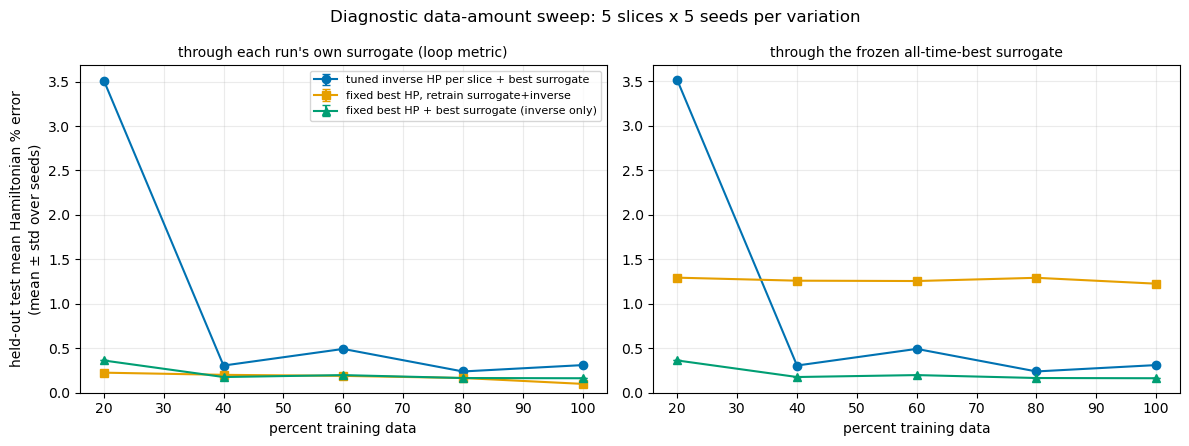

In [22]:
# Diagnostic comparison: held-out test error vs training-data amount, per variation,
# mean over seeds (error bars only appear if SEEDS has more than one entry).
#
# Left panel: the loop metric, measured through each run's own surrogate (what the
# ml_38/ml_39 sweeps plot). Right panel: the same trained inverse models measured
# through the frozen all-time-best surrogate -- a constant yardstick. If the
# fixed-HP variations recover a downward trend on the right while the loop metric
# on the left stays flat/noisy, the missing trend in interp_v1 came from per-slice
# HP retuning and/or the per-slice surrogate changing the yardstick, not from the
# inverse model failing to benefit from data.
import matplotlib.pyplot as plt

# Okabe-Ito colorblind-safe hues, fixed assignment per variation; marker shape is
# the secondary encoding.
VAR_STYLE = {
    VARIATION_TUNED_INVERSE:            ("#0072B2", "o", "tuned inverse HP per slice + best surrogate"),
    VARIATION_FIXED_HP_RETRAIN_BOTH:    ("#E69F00", "s", "fixed best HP, retrain surrogate+inverse"),
    VARIATION_FIXED_HP_FIXED_SURROGATE: ("#009E73", "^", "fixed best HP + best surrogate (inverse only)"),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
panels = (
    (axes[0], "test_mean_hamiltonian_pct", "through each run's own surrogate (loop metric)"),
    (axes[1], "test_mean_hamiltonian_pct_via_best_surrogate", "through the frozen all-time-best surrogate"),
)

for variation, (color, marker, label) in VAR_STYLE.items():
    df_var = sweep_frames.get(variation)
    if df_var is None or not len(df_var):
        continue
    for ax, col, _title in panels:
        if col not in df_var.columns:
            continue
        g = df_var.groupby("training_percent")[col].agg(["mean", "std"]).reset_index()
        ax.errorbar(g["training_percent"], g["mean"], yerr=g["std"].fillna(0.0),
                    color=color, marker=marker, capsize=3, lw=1.5, ms=6, label=label)

for ax, _col, title in panels:
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("percent training data")
    ax.grid(alpha=0.25)
    ax.set_ylim(bottom=0)
axes[0].set_ylabel("held-out test mean Hamiltonian % error\n(mean $\\pm$ std over seeds)")
axes[0].legend(fontsize=8)
fig.suptitle("Diagnostic data-amount sweep: 5 slices x 5 seeds per variation")
fig.tight_layout()

plot_dir = EXPERIMENT_DIR / "plots"
plot_dir.mkdir(exist_ok=True)
fig.savefig(plot_dir / "uniform_diagnostic_sweep_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


## Surrogate-only data-amount sweep

The three variations above all measure the *inverse* model. This section sweeps the training-data amount
for **just the forward surrogate**: on each of the same 5 nested uniform slices (20/40/60/80/100% of the
training pool), a fresh surrogate is trained with the **fixed all-time-best surrogate hyperparameters**
(read straight out of `best_keras_model_model2_surrogate.keras`, no per-slice retuning), and its percent
error is evaluated directly on the held-out uniform test set. No inverse model is involved anywhere.

Because the surrogate is small and fast to train, this sweep averages over several seeds
(`SURROGATE_ONLY_SEEDS`), unlike the single-seed variations above.

Cross-check: the seed-1 rows here should closely match the `surrogate_test_*` columns of
`fixed_hp_retrain_both`, which trains the identical surrogate per slice as a byproduct
(same builder, same subsets, same seed); the summary cell prints that comparison when the
variation-2 CSV is available.

Outputs:

- `data_amount_sweep_uniform_diag_surrogate_only.csv` — one row per (fraction, seed)
- `data_amount_sweep_uniform_diag_surrogate_only_summary.csv` — across-seed mean/std per fraction
- models under `model/uniform_diagnostic_sweep/surrogate_only/`
- `plots/uniform_diagnostic_sweep_surrogate_only.png`


In [23]:
# Surrogate-only sweep: retrain just the forward surrogate on each training slice
# with the all-time-best surrogate hyperparameters (no retuning), then evaluate
# its percent error directly on the held-out uniform test set. Same (fraction,
# seed) resume machinery as the main sweep above.

VARIATION_SURROGATE_ONLY = "surrogate_only"
# The surrogate trains in well under a minute per slice, so average over seeds.
SURROGATE_ONLY_SEEDS = (1, 2, 3, 4, 5)
# Set to False if the CSV already exists and you only want the summary/plot cells.
RUN_SURROGATE_ONLY_SWEEP = True

surrogate_only_csv = sweep_csv_path(VARIATION_SURROGATE_ONLY)
surrogate_only_model_dir = SWEEP_MODEL_ROOT / VARIATION_SURROGATE_ONLY
surrogate_only_model_dir.mkdir(parents=True, exist_ok=True)

if RUN_SURROGATE_ONLY_SWEEP:
    n_train_pool = len(train_pool_idx)
    if surrogate_only_csv.exists():
        so_rows = pd.read_csv(surrogate_only_csv).to_dict("records")
        so_done = {(int(round(r["fraction"] * 100)), int(r["seed"])) for r in so_rows}
        print(f"### {VARIATION_SURROGATE_ONLY}: resuming from {surrogate_only_csv.name} ({len(so_rows)} existing rows)")
    else:
        so_rows, so_done = [], set()
        print(f"### {VARIATION_SURROGATE_ONLY}: starting fresh -> {surrogate_only_csv.name}")

    for seed in SURROGATE_ONLY_SEEDS:
        for fraction in FRACTIONS:
            pct = int(round(fraction * 100))
            if (pct, seed) in so_done:
                print(f"  skip {pct}% seed {seed} (already complete)")
                continue

            n_subset = max(1, int(round(fraction * n_train_pool)))
            subset_idx = train_pool_idx[uniform_order[:n_subset]]
            print(f"  === {VARIATION_SURROGATE_ONLY} | seed {seed} | {pct}% of pool ({n_subset} samples) ===")

            surrogate_model = build_surrogate_reference(seed)
            surrogate_best_val_loss, surrogate_best_epoch = train_surrogate_fixed(
                surrogate_model,
                geom_surrogate_scaled[subset_idx], h_model_scaled[subset_idx],
                geom_surrogate_scaled[val_idx], h_model_scaled[val_idx],
            )
            surrogate_model_path = surrogate_only_model_dir / f"fraction_{pct:03d}pct_seed{seed}_surrogate.keras"
            surrogate_model.save(surrogate_model_path)

            train_metrics = evaluate_surrogate_model(surrogate_model, geom_surrogate_scaled[subset_idx], h_raw[subset_idx])
            val_metrics = evaluate_surrogate_model(surrogate_model, geom_surrogate_scaled[val_idx], h_raw[val_idx])
            test_metrics = evaluate_surrogate_model(surrogate_model, geom_surrogate_scaled[test_idx], h_raw[test_idx])

            del surrogate_model
            tf.keras.backend.clear_session()
            gc.collect()

            so_rows.append(
                {
                    "selection_method": "uniform_random_split_nested_random_subsets_diagnostic",
                    "variation": VARIATION_SURROGATE_ONLY,
                    "split_seed": SPLIT_SEED,
                    "fraction": fraction,
                    "training_percent": fraction * 100.0,
                    "n_samples": n_subset,
                    "seed": seed,
                    "hyperparameter_source": str(BEST_SURROGATE_MODEL_PATH),
                    "surrogate_training_mode": "fixed_best_hp_retrained_per_slice",
                    "saved_surrogate_model_path": str(surrogate_model_path),
                    "surrogate_dense_units": json.dumps(REFERENCE_SURROGATE_HP["hidden_units"]),
                    "surrogate_optimizer": "Adam",
                    "surrogate_learning_rate": SURROGATE_LEARNING_RATE_LABEL,
                    "surrogate_dropout_rate": REFERENCE_SURROGATE_HP["dropout_rate"],
                    "surrogate_l2_reg": REFERENCE_SURROGATE_HP["l2_reg"],
                    "surrogate_use_batchnorm": REFERENCE_SURROGATE_HP["use_batchnorm"],
                    "surrogate_reconstruction_loss": str(SURROGATE_RECONSTRUCTION_LOSS),
                    "surrogate_best_val_loss": surrogate_best_val_loss,
                    "surrogate_best_epoch": surrogate_best_epoch,
                    "surrogate_jit_compile": SURROGATE_JIT_COMPILE,
                    "surrogate_batch_size": SURROGATE_TRAIN_BATCH_SIZE,
                    "surrogate_early_stopping_patience": SURROGATE_TRAIN_EARLY_STOPPING_PATIENCE,
                    **{f"surrogate_train_{key}": value for key, value in train_metrics.items()},
                    **{f"surrogate_val_{key}": value for key, value in val_metrics.items()},
                    **{f"surrogate_test_{key}": value for key, value in test_metrics.items()},
                }
            )

            # Write incrementally so an interrupted sweep resumes cleanly.
            pd.DataFrame(so_rows).to_csv(surrogate_only_csv, index=False)
            print(f"    test: f_q {test_metrics['omega_q_mean_pct']:.3f}%  alpha {test_metrics['alpha_mean_pct']:.3f}%")

surrogate_only_df = pd.read_csv(surrogate_only_csv) if surrogate_only_csv.exists() else None
if surrogate_only_df is not None:
    print(f"\nsurrogate-only sweep rows: {len(surrogate_only_df)}")


### surrogate_only: starting fresh -> data_amount_sweep_uniform_diag_surrogate_only.csv
  === surrogate_only | seed 1 | 20% of pool (270 samples) ===
    test: f_q 0.256%  alpha 0.611%
  === surrogate_only | seed 1 | 40% of pool (541 samples) ===
    test: f_q 0.171%  alpha 0.469%
  === surrogate_only | seed 1 | 60% of pool (811 samples) ===
    test: f_q 0.170%  alpha 0.465%
  === surrogate_only | seed 1 | 80% of pool (1082 samples) ===
    test: f_q 0.111%  alpha 0.290%
  === surrogate_only | seed 1 | 100% of pool (1352 samples) ===
    test: f_q 0.160%  alpha 0.456%
  === surrogate_only | seed 2 | 20% of pool (270 samples) ===
    test: f_q 0.262%  alpha 0.731%
  === surrogate_only | seed 2 | 40% of pool (541 samples) ===
    test: f_q 0.165%  alpha 0.456%
  === surrogate_only | seed 2 | 60% of pool (811 samples) ===
    test: f_q 0.158%  alpha 0.447%
  === surrogate_only | seed 2 | 80% of pool (1082 samples) ===
    test: f_q 0.143%  alpha 0.387%
  === surrogate_only | seed 2 | 100

In [24]:
# Across-seed summary for the surrogate-only sweep, with per-parameter columns
# (f_q and alpha are what the plot below shows). Also cross-checks the seed-1
# rows against the surrogate_test_* columns recorded by fixed_hp_retrain_both,
# which trains the identical surrogate per slice as a byproduct.

if surrogate_only_df is not None and len(surrogate_only_df):
    surrogate_only_summary = (
        surrogate_only_df.groupby(["training_percent", "n_samples"], as_index=False)
        .agg(
            n_seeds=("seed", "nunique"),
            train_mean=("surrogate_train_mean_hamiltonian_pct", "mean"),
            train_std=("surrogate_train_mean_hamiltonian_pct", "std"),
            val_mean=("surrogate_val_mean_hamiltonian_pct", "mean"),
            val_std=("surrogate_val_mean_hamiltonian_pct", "std"),
            test_mean=("surrogate_test_mean_hamiltonian_pct", "mean"),
            test_std=("surrogate_test_mean_hamiltonian_pct", "std"),
            test_fq_mean=("surrogate_test_omega_q_mean_pct", "mean"),
            test_fq_std=("surrogate_test_omega_q_mean_pct", "std"),
            test_alpha_mean=("surrogate_test_alpha_mean_pct", "mean"),
            test_alpha_std=("surrogate_test_alpha_mean_pct", "std"),
        )
        .sort_values("training_percent")
    )
    out_path = summary_csv_path(VARIATION_SURROGATE_ONLY)
    surrogate_only_summary.to_csv(out_path, index=False)
    print(f"{VARIATION_SURROGATE_ONLY} -> {out_path.name}")
    print(surrogate_only_summary.to_string(index=False))

    retrain_both_csv = sweep_csv_path(VARIATION_FIXED_HP_RETRAIN_BOTH)
    if retrain_both_csv.exists():
        v2 = pd.read_csv(retrain_both_csv)
        merged = surrogate_only_df.merge(
            v2[["fraction", "seed", "surrogate_test_mean_hamiltonian_pct"]],
            on=["fraction", "seed"],
            suffixes=("", "_retrain_both"),
        )
        if len(merged):
            print("\nCross-check vs fixed_hp_retrain_both (same seed/fraction, should closely match):")
            print(
                merged[
                    [
                        "fraction",
                        "seed",
                        "surrogate_test_mean_hamiltonian_pct",
                        "surrogate_test_mean_hamiltonian_pct_retrain_both",
                    ]
                ].to_string(index=False)
            )
else:
    print("no surrogate-only rows yet; run the sweep cell above first")


surrogate_only -> data_amount_sweep_uniform_diag_surrogate_only_summary.csv
 training_percent  n_samples  n_seeds  train_mean  train_std  val_mean  val_std  test_mean  test_std  test_fq_mean  test_fq_std  test_alpha_mean  test_alpha_std
             20.0        270        5    0.309160   0.028153  0.435818 0.038304   0.454277  0.041238      0.248383     0.019657         0.660172        0.065871
             40.0        541        5    0.279250   0.032544  0.323887 0.031394   0.336148  0.039753      0.182324     0.023748         0.489972        0.055863
             60.0        811        5    0.261955   0.033526  0.296977 0.046124   0.290487  0.038638      0.161948     0.019186         0.419027        0.060166
             80.0       1082        5    0.269791   0.051613  0.292588 0.051106   0.286572  0.059213      0.154854     0.032766         0.418290        0.086267
            100.0       1352        5    0.249123   0.030901  0.254119 0.039564   0.272030  0.046194      0.150671     

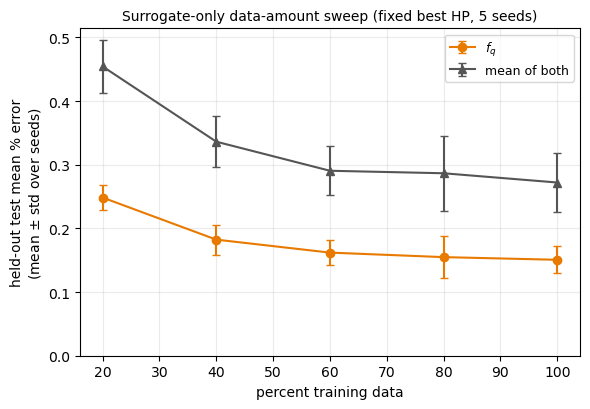

In [26]:
# Surrogate-only held-out test error vs training-data amount, mean +/- std over
# seeds. Colors follow the paper convention: orange for f_q, purple for alpha.
import matplotlib.pyplot as plt

if surrogate_only_df is not None and len(surrogate_only_df):
    SURR_SERIES = (
        ("surrogate_test_omega_q_mean_pct", "#E87A00", "o", r"$f_q$"),
        #("surrogate_test_alpha_mean_pct", "#7B68AE", "s", r"$\alpha$"),
        ("surrogate_test_mean_hamiltonian_pct", "#555555", "^", "mean of both"),
    )

    fig, ax = plt.subplots(figsize=(6.0, 4.2))
    for col, color, marker, label in SURR_SERIES:
        g = surrogate_only_df.groupby("training_percent")[col].agg(["mean", "std"]).reset_index()
        ax.errorbar(
            g["training_percent"], g["mean"], yerr=g["std"].fillna(0.0),
            color=color, marker=marker, capsize=3, lw=1.5, ms=6, label=label,
        )

    n_seeds_used = surrogate_only_df["seed"].nunique()
    ax.set_xlabel("percent training data")
    ax.set_ylabel("held-out test mean % error\n(mean $\\pm$ std over seeds)")
    ax.set_title(
        f"Surrogate-only data-amount sweep (fixed best HP, {n_seeds_used} seed{'s' if n_seeds_used != 1 else ''})",
        fontsize=10,
    )
    ax.grid(alpha=0.25)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)
    fig.tight_layout()

    plot_dir = EXPERIMENT_DIR / "plots"
    plot_dir.mkdir(exist_ok=True)
    fig.savefig(plot_dir / "uniform_diagnostic_sweep_surrogate_only.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("no surrogate-only rows yet; run the sweep cell above first")


### Surrogate-only sweep with per-slice Keras-tuner search

Same surrogate-only data-amount sweep as above, but with the hyperparameters **re-tuned at every
training fraction** on a finer **10-slice grid (10/20/.../100% of the training pool)**.

To fit a realistic time budget, the tuner search is decoupled from the seed averaging:

1. **One Keras-tuner search per fraction** (`SURROGATE_TUNER_TRIALS = 100` Bayesian-optimization
   trials, search space copied from ml_38's per-fraction surrogate search, which mirrors ml_11).
   The search is the expensive part.
2. **The winning hyperparameters are then retrained from scratch once per seed**
   (`SURROGATE_TUNED_SEEDS`). A refit is a single training run, so seeds are nearly free; they
   measure the training-noise spread of the *chosen* architecture rather than re-running the
   whole search per seed.

Total cost is therefore dominated by 10 searches x 100 trials = 1{,}000 candidate fits (order
minutes-per-search x 10 on an A100), plus 50 cheap refits — comfortably inside an overnight run,
unlike tuning per (fraction, seed) which would multiply the search cost by the seed count.

Everything resumes: finished (fraction, seed) rows are skipped via the CSV, and a partially
finished tuner search continues from its saved trials (`overwrite=False`).

Outputs (same naming pattern, `{variation} = surrogate_only_tuned_hp`):

- `data_amount_sweep_uniform_diag_surrogate_only_tuned_hp.csv` (+ `_summary.csv`)
- tuner trials under `kt_dir2/surrogate_only_tuned_hp/`, models under `model/uniform_diagnostic_sweep/surrogate_only_tuned_hp/`
- `plots/uniform_diagnostic_sweep_surrogate_only_tuned_vs_fixed.png`


In [ ]:
# Surrogate-only sweep with a per-fraction Keras-tuner search on a finer
# 10-slice grid. One search per fraction (the expensive part), then the winning
# HPs are refit once per seed (cheap) for error bars. Search space / tuner
# settings copied from ml_38's make_surrogate_hypermodel, which mirrors ml_11.
import time

import keras_tuner as kt

VARIATION_SURROGATE_ONLY_TUNED = "surrogate_only_tuned_hp"
SURROGATE_TUNED_SEEDS = (1, 2, 3, 4, 5)  # refit seeds; cheap, one training run each
SURROGATE_TUNER_SEED = 1                 # seed for the tuner search itself (one per fraction)
SURROGATE_TUNER_TRIALS = 100
SURROGATE_TUNER_EXECUTIONS_PER_TRIAL = 1
SURROGATE_TUNER_MAX_CONSEC_FAILURES = 8
SURROGATE_TUNER_OVERWRITE = False  # False lets an interrupted search resume its trials
# Finer grid than the notebook-wide FRACTIONS: every 10% of the training pool.
SURROGATE_TUNED_FRACTIONS = tuple(round(0.1 * k, 1) for k in range(1, 11))
SURROGATE_TUNER_DIR = EXPERIMENT_DIR / "kt_dir2" / VARIATION_SURROGATE_ONLY_TUNED
SURROGATE_TUNER_DIR.mkdir(parents=True, exist_ok=True)
# Set to False if the CSV already exists and you only want the summary/plot cells.
RUN_SURROGATE_ONLY_TUNED_SWEEP = True


def make_surrogate_hypermodel(input_dim: int, output_dim: int):
    """Surrogate (geometry -> Hamiltonian) hypermodel, search space from ml_11/ml_38."""
    def build(hp):
        tf.keras.backend.clear_session()
        gc.collect()

        n_layers = hp.Int("n_layers", min_value=1, max_value=1, default=1)
        neurons_per_layer = [hp.Int(f"neurons_{i}", min_value=32, max_value=1024, step=32) for i in range(n_layers)]
        dropout_rate = hp.Float("dropout_rate", 0.0, 0.45, step=0.05)
        l2_reg = hp.Float("l2_reg", 1e-5, 1e-2, sampling="LOG", default=1e-4)
        lr_initial = hp.Float("learning_rate", 3e-2, 1e-1, sampling="LOG", default=3e-2)
        use_batchnorm = hp.Boolean("use_batchnorm", default=True)

        model = Sequential(name="tuned_surrogate")
        model.add(Input(shape=(input_dim,), name="input1"))
        for i, n_units in enumerate(neurons_per_layer):
            model.add(Dense(n_units, name=f"fc{i}", kernel_initializer="he_normal",
                            kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
            if use_batchnorm:
                model.add(BatchNormalization(name=f"bn{i}"))
            model.add(LeakyReLU(negative_slope=0.01, name=f"leaky_relu{i}"))
            model.add(Dropout(rate=dropout_rate, name=f"dropout{i}"))
        model.add(Dense(output_dim, name="output", kernel_initializer="he_normal"))
        model.compile(optimizer=tf.optimizers.Adam(learning_rate=lr_initial),
                      loss=SURROGATE_TRAIN_LOSS, metrics=[SURROGATE_TRAIN_LOSS])
        return model
    return build


def tune_surrogate_only_for_subset(geom_subset_scaled, h_subset_scaled, fraction):
    """One Bayesian-optimization search for this fraction; returns (tuner, best_hp, stats)."""
    pct = int(round(fraction * 100))
    tuner = kt.BayesianOptimization(
        make_surrogate_hypermodel(geom_subset_scaled.shape[1], h_subset_scaled.shape[1]),
        objective="val_loss",
        max_trials=SURROGATE_TUNER_TRIALS,
        executions_per_trial=SURROGATE_TUNER_EXECUTIONS_PER_TRIAL,
        max_consecutive_failed_trials=SURROGATE_TUNER_MAX_CONSEC_FAILURES,
        seed=SURROGATE_TUNER_SEED,
        directory=str(SURROGATE_TUNER_DIR),
        project_name=f"frac{pct:03d}",
        overwrite=SURROGATE_TUNER_OVERWRITE,
    )
    early_stopping = EarlyStopping(monitor="val_loss", mode="min",
                                   patience=SURROGATE_TRAIN_EARLY_STOPPING_PATIENCE,
                                   restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                  patience=max(10, SURROGATE_TRAIN_EARLY_STOPPING_PATIENCE // 3),
                                  min_lr=1e-6, verbose=0)
    tuner.search(
        np.asarray(geom_subset_scaled, dtype="float32"),
        np.asarray(h_subset_scaled, dtype="float32"),
        epochs=SURROGATE_EPOCHS,
        batch_size=SURROGATE_TRAIN_BATCH_SIZE,
        validation_data=(np.asarray(geom_surrogate_scaled[val_idx], dtype="float32"),
                         np.asarray(h_model_scaled[val_idx], dtype="float32")),
        callbacks=[early_stopping, reduce_lr],
        verbose=0,
    )
    best_hp = tuner.get_best_hyperparameters(1)[0]
    try:
        trial = tuner.oracle.get_best_trials(1)[0]
        best_val_loss = float(trial.score) if trial.score is not None else float("nan")
        best_step = int(trial.best_step) if trial.best_step is not None else -1
    except Exception:
        best_val_loss, best_step = float("nan"), -1
    return tuner, best_hp, best_val_loss, best_step


surrogate_only_tuned_csv = sweep_csv_path(VARIATION_SURROGATE_ONLY_TUNED)
surrogate_only_tuned_model_dir = SWEEP_MODEL_ROOT / VARIATION_SURROGATE_ONLY_TUNED
surrogate_only_tuned_model_dir.mkdir(parents=True, exist_ok=True)

if RUN_SURROGATE_ONLY_TUNED_SWEEP:
    n_train_pool = len(train_pool_idx)
    if surrogate_only_tuned_csv.exists():
        sot_rows = pd.read_csv(surrogate_only_tuned_csv).to_dict("records")
        sot_done = {(int(round(r["fraction"] * 100)), int(r["seed"])) for r in sot_rows}
        print(f"### {VARIATION_SURROGATE_ONLY_TUNED}: resuming from {surrogate_only_tuned_csv.name} ({len(sot_rows)} existing rows)")
    else:
        sot_rows, sot_done = [], set()
        print(f"### {VARIATION_SURROGATE_ONLY_TUNED}: starting fresh -> {surrogate_only_tuned_csv.name}")

    for fraction in SURROGATE_TUNED_FRACTIONS:
        pct = int(round(fraction * 100))
        missing_seeds = [s for s in SURROGATE_TUNED_SEEDS if (pct, s) not in sot_done]
        if not missing_seeds:
            print(f"  skip {pct}% (all seeds already complete)")
            continue

        n_subset = max(1, int(round(fraction * n_train_pool)))
        subset_idx = train_pool_idx[uniform_order[:n_subset]]

        # ---- one tuner search for this fraction (resumes from saved trials) ----
        print(f"  === {VARIATION_SURROGATE_ONLY_TUNED} | {pct}% of pool ({n_subset} samples) | "
              f"search: {SURROGATE_TUNER_TRIALS} trials ===")
        t0 = time.monotonic()
        tuner, best_hp, tuner_best_val_loss, tuner_best_step = tune_surrogate_only_for_subset(
            geom_surrogate_scaled[subset_idx], h_model_scaled[subset_idx], fraction,
        )
        search_minutes = (time.monotonic() - t0) / 60.0
        n_layers_best = int(best_hp.get("n_layers"))
        units_best = [int(best_hp.get(f"neurons_{i}")) for i in range(n_layers_best)]
        print(f"    search done in {search_minutes:.1f} min | best: units {units_best}, "
              f"lr {float(best_hp.get('learning_rate')):.2e}, dropout {float(best_hp.get('dropout_rate')):.2f}, "
              f"bn {bool(best_hp.get('use_batchnorm'))}")

        # ---- cheap refits: winning HPs retrained from scratch once per seed ----
        for seed in missing_seeds:
            tf.keras.utils.set_random_seed(seed)
            surrogate_model = tuner.hypermodel.build(best_hp)
            refit_best_val_loss, refit_best_epoch = train_surrogate_fixed(
                surrogate_model,
                geom_surrogate_scaled[subset_idx], h_model_scaled[subset_idx],
                geom_surrogate_scaled[val_idx], h_model_scaled[val_idx],
            )
            surrogate_model_path = surrogate_only_tuned_model_dir / f"fraction_{pct:03d}pct_seed{seed}_surrogate.keras"
            surrogate_model.save(surrogate_model_path)

            train_metrics = evaluate_surrogate_model(surrogate_model, geom_surrogate_scaled[subset_idx], h_raw[subset_idx])
            val_metrics = evaluate_surrogate_model(surrogate_model, geom_surrogate_scaled[val_idx], h_raw[val_idx])
            test_metrics = evaluate_surrogate_model(surrogate_model, geom_surrogate_scaled[test_idx], h_raw[test_idx])

            del surrogate_model
            tf.keras.backend.clear_session()
            gc.collect()

            sot_rows.append(
                {
                    "selection_method": "uniform_random_split_nested_random_subsets_diagnostic",
                    "variation": VARIATION_SURROGATE_ONLY_TUNED,
                    "split_seed": SPLIT_SEED,
                    "fraction": fraction,
                    "training_percent": fraction * 100.0,
                    "n_samples": n_subset,
                    "seed": seed,
                    "hyperparameter_source": f"keras_tuner_per_fraction ({SURROGATE_TUNER_DIR.name}/frac{pct:03d})",
                    "surrogate_training_mode": "keras_tuner_per_fraction_refit_per_seed",
                    "saved_surrogate_model_path": str(surrogate_model_path),
                    "surrogate_dense_units": json.dumps(units_best),
                    "surrogate_optimizer": "Adam",
                    "surrogate_learning_rate": float(best_hp.get("learning_rate")),
                    "surrogate_dropout_rate": float(best_hp.get("dropout_rate")),
                    "surrogate_l2_reg": float(best_hp.get("l2_reg")),
                    "surrogate_use_batchnorm": bool(best_hp.get("use_batchnorm")),
                    "surrogate_reconstruction_loss": str(SURROGATE_TRAIN_LOSS),
                    "surrogate_best_val_loss": refit_best_val_loss,
                    "surrogate_best_epoch": refit_best_epoch,
                    "surrogate_tuner_seed": SURROGATE_TUNER_SEED,
                    "surrogate_tuner_trials": SURROGATE_TUNER_TRIALS,
                    "surrogate_tuner_best_val_loss": tuner_best_val_loss,
                    "surrogate_tuner_best_epoch": tuner_best_step,
                    "surrogate_batch_size": SURROGATE_TRAIN_BATCH_SIZE,
                    "surrogate_early_stopping_patience": SURROGATE_TRAIN_EARLY_STOPPING_PATIENCE,
                    **{f"surrogate_train_{key}": value for key, value in train_metrics.items()},
                    **{f"surrogate_val_{key}": value for key, value in val_metrics.items()},
                    **{f"surrogate_test_{key}": value for key, value in test_metrics.items()},
                }
            )

            # Write incrementally so an interrupted sweep resumes cleanly.
            pd.DataFrame(sot_rows).to_csv(surrogate_only_tuned_csv, index=False)
            print(f"    seed {seed}: test f_q {test_metrics['omega_q_mean_pct']:.3f}%  "
                  f"alpha {test_metrics['alpha_mean_pct']:.3f}%")

        del tuner
        tf.keras.backend.clear_session()
        gc.collect()

surrogate_only_tuned_df = pd.read_csv(surrogate_only_tuned_csv) if surrogate_only_tuned_csv.exists() else None
if surrogate_only_tuned_df is not None:
    print(f"\ntuned surrogate-only sweep rows: {len(surrogate_only_tuned_df)}")


In [ ]:
# Across-slice summary for the tuned surrogate-only sweep, including the
# per-slice tuner-chosen hyperparameters so it is obvious how much the
# architecture moves from fraction to fraction.

if surrogate_only_tuned_df is not None and len(surrogate_only_tuned_df):
    surrogate_only_tuned_summary = (
        surrogate_only_tuned_df.groupby(["training_percent", "n_samples"], as_index=False)
        .agg(
            n_seeds=("seed", "nunique"),
            train_mean=("surrogate_train_mean_hamiltonian_pct", "mean"),
            train_std=("surrogate_train_mean_hamiltonian_pct", "std"),
            val_mean=("surrogate_val_mean_hamiltonian_pct", "mean"),
            val_std=("surrogate_val_mean_hamiltonian_pct", "std"),
            test_mean=("surrogate_test_mean_hamiltonian_pct", "mean"),
            test_std=("surrogate_test_mean_hamiltonian_pct", "std"),
            test_fq_mean=("surrogate_test_omega_q_mean_pct", "mean"),
            test_fq_std=("surrogate_test_omega_q_mean_pct", "std"),
            test_alpha_mean=("surrogate_test_alpha_mean_pct", "mean"),
            test_alpha_std=("surrogate_test_alpha_mean_pct", "std"),
        )
        .sort_values("training_percent")
    )
    out_path = summary_csv_path(VARIATION_SURROGATE_ONLY_TUNED)
    surrogate_only_tuned_summary.to_csv(out_path, index=False)
    print(f"{VARIATION_SURROGATE_ONLY_TUNED} -> {out_path.name}")
    print(surrogate_only_tuned_summary.to_string(index=False))

    print("\nPer-fraction tuner-chosen hyperparameters (one search per fraction, shared by all refit seeds):")
    hp_cols = [
        "training_percent", "surrogate_dense_units", "surrogate_learning_rate",
        "surrogate_dropout_rate", "surrogate_l2_reg", "surrogate_use_batchnorm",
    ]
    if "surrogate_tuner_best_val_loss" in surrogate_only_tuned_df.columns:
        hp_cols.append("surrogate_tuner_best_val_loss")
    hp_table = surrogate_only_tuned_df[hp_cols].drop_duplicates(subset=["training_percent"]).sort_values("training_percent")
    print(hp_table.to_string(index=False))
else:
    print("no tuned surrogate-only rows yet; run the sweep cell above first")


In [ ]:
# Fixed-HP vs per-slice-tuned surrogate-only test error vs training-data amount.
# Solid lines: fixed all-time-best HP (mean +/- std over SURROGATE_ONLY_SEEDS).
# Dashed lines with open markers: Keras tuner per slice (single seed).
# Paper colors: orange f_q, purple alpha.
import matplotlib.pyplot as plt

fixed_df = pd.read_csv(sweep_csv_path(VARIATION_SURROGATE_ONLY)) if sweep_csv_path(VARIATION_SURROGATE_ONLY).exists() else None
tuned_df = pd.read_csv(sweep_csv_path(VARIATION_SURROGATE_ONLY_TUNED)) if sweep_csv_path(VARIATION_SURROGATE_ONLY_TUNED).exists() else None

series = (
    ("surrogate_test_omega_q_mean_pct", "#E87A00", "o", r"$f_q$"),
    ("surrogate_test_alpha_mean_pct", "#7B68AE", "s", r"$\alpha$"),
)

fig, ax = plt.subplots(figsize=(6.0, 4.2))
for df_variant, linestyle, face, suffix in (
    (fixed_df, "-", None, "fixed best HP"),
    (tuned_df, "--", "white", "tuned per slice"),
):
    if df_variant is None or not len(df_variant):
        continue
    for col, color, marker, label in series:
        g = df_variant.groupby("training_percent")[col].agg(["mean", "std"]).reset_index()
        ax.errorbar(
            g["training_percent"], g["mean"], yerr=g["std"].fillna(0.0),
            color=color, marker=marker, markerfacecolor=face if face else color,
            markeredgecolor=color, linestyle=linestyle, capsize=3, lw=1.5, ms=6,
            label=f"{label} {suffix}",
        )

ax.set_xlabel("percent training data")
ax.set_ylabel("held-out test mean % error")
ax.set_title("Surrogate-only sweep: fixed best HP vs Keras tuner per slice", fontsize=10)
ax.grid(alpha=0.25)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
fig.tight_layout()

plot_dir = EXPERIMENT_DIR / "plots"
plot_dir.mkdir(exist_ok=True)
fig.savefig(plot_dir / "uniform_diagnostic_sweep_surrogate_only_tuned_vs_fixed.png", dpi=200, bbox_inches="tight")
plt.show()
